## DBSCAN
Density Based Spatial CLustering of Application with Noice

In [ ]:
import pandas as pd
import numpy as np
from  sklearn.cluster import  DBSCAN

df=pd.read_csv("../../Data/Nepal_RoadAccidents_Cleaned.csv")
coords=np.radians(df[['Latitude','Longitude']].values) #convert degree to radians
db = DBSCAN(
    eps=0.005,          # radius = ~63km
    min_samples=3,     # minimum 3 accidents to form a cluster
    metric='haversine' # spherical distance formula for lat/lon
).fit(coords)

df['Cluster'] = db.labels_ # assign cluster labels to dataframe
print(df[['Latitude', 'Longitude', 'Cluster']].head())

n_clusters=len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise=(db.labels_==-1).sum()


print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(df['Cluster'].value_counts().sort_index())



    Latitude  Longitude  Cluster
0  26.741281  85.901595        0
1  28.536148  81.114083        1
2  26.682029  85.990802        0
3  27.561145  83.367298        2
4  28.585167  81.645046        3
Number of clusters: 7
Number of noise points: 0
Cluster
0    83
1    86
2    79
3    77
4    66
5    95
6    64
Name: count, dtype: int64


## Silhoutte Score

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

df = pd.read_csv('../../Data/Nepal_RoadAccidents_Cleaned.csv')
coords = np.radians(df[['Latitude', 'Longitude']].values)

db = DBSCAN(eps=0.005, min_samples=3, metric='haversine').fit(coords)
df['Cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = (db.labels_ == -1).sum()

print(f'Clusters: {n_clusters}')
print(f'Noise:    {n_noise}')
print(df['Cluster'].value_counts().sort_index())

# Silhouette Score
mask         = df['Cluster'] != -1
coords_clean = coords[mask]
labels_clean = db.labels_[mask]

score = silhouette_score(coords_clean, labels_clean, metric='haversine')
print(f'\nSilhouette Score: {score:.4f}')

# Interpretation
if score >= 0.7:
    print('Result: Strong clusters ')
elif score >= 0.5:
    print('Result: Reasonable clusters ')
elif score >= 0.3:
    print('Result: Weak clusters ')
else:
    print('Result: Poor clusters ')

Clusters: 7
Noise:    0
Cluster
0    83
1    86
2    79
3    77
4    66
5    95
6    64
Name: count, dtype: int64

Silhouette Score: 0.8951
Result: Strong clusters 


In [ ]:
import folium
COLORS = ['red','blue','green','purple','orange','darkred',
          'cadetblue','darkgreen','darkpurple','lightred']

m_cluster=folium.Map(location=[27.7, 84.0], zoom_start=7, tiles='CartoDB positron')

for _, row in df.iterrows():
    cluster=row['Cluster']
    color='grey' if cluster == -1 else COLORS[cluster % len(COLORS)]
    label = 'Noise' if cluster == -1 else f'Cluster {cluster}'
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f'<b>{label}</b><br>'
            f'Location: {row["City / Place"]}, {row["District"]}<br>'
            f'Vehicle: {row["Vehicle_Type"]} | Cause: {row["Accident_Cause"]}<br>'
            f'Fatalities: {int(row["Fatalities"])} | Weather: {row["Weather_Condition"]}',
            max_width=250
        ) 
    ).add_to(m_cluster)

  

m_cluster.save("fig/Nepal_Accident_Clusters.html")
print("Cluster map saved as 'Nepal_Accident_Clusters.html'")





Cluster map saved as 'Nepal_Accident_Clusters.html'


In [17]:
cluster_profile = df[df['Cluster'] != -1].groupby('Cluster').agg(
    Accidents      = ('Accident_ID', 'count'),
    Avg_Fatalities = ('Fatalities', 'mean'),
    Total_Injuries = ('Injuries', 'sum'),
    Top_Cause      = ('Accident_Cause', lambda x: x.mode()[0]),
    Top_Vehicle    = ('Vehicle_Type', lambda x: x.mode()[0]),
    Top_District   = ('District', lambda x: x.mode()[0]),
).round(2)

print('=== Cluster Profiles ===')
print(cluster_profile.to_string())

=== Cluster Profiles ===
         Accidents  Avg_Fatalities  Total_Injuries       Top_Cause Top_Vehicle Top_District
Cluster                                                                                    
0               83            1.28             282       Landslide  Motorcycle     Dhanusha
1               86            1.12             283           Flood  Motorcycle      Kailali
2               79            1.03             286         Weather  Motorcycle    Rupandehi
3               77            1.42             269       Landslide  Motorcycle      Surkhet
4               66            1.23             233       Landslide  Motorcycle       Morang
5               95            0.92             268    Overspeeding  Motorcycle        Kaski
6               64            1.08             185  Road Condition  Motorcycle    Kathmandu


## Accident By province and district

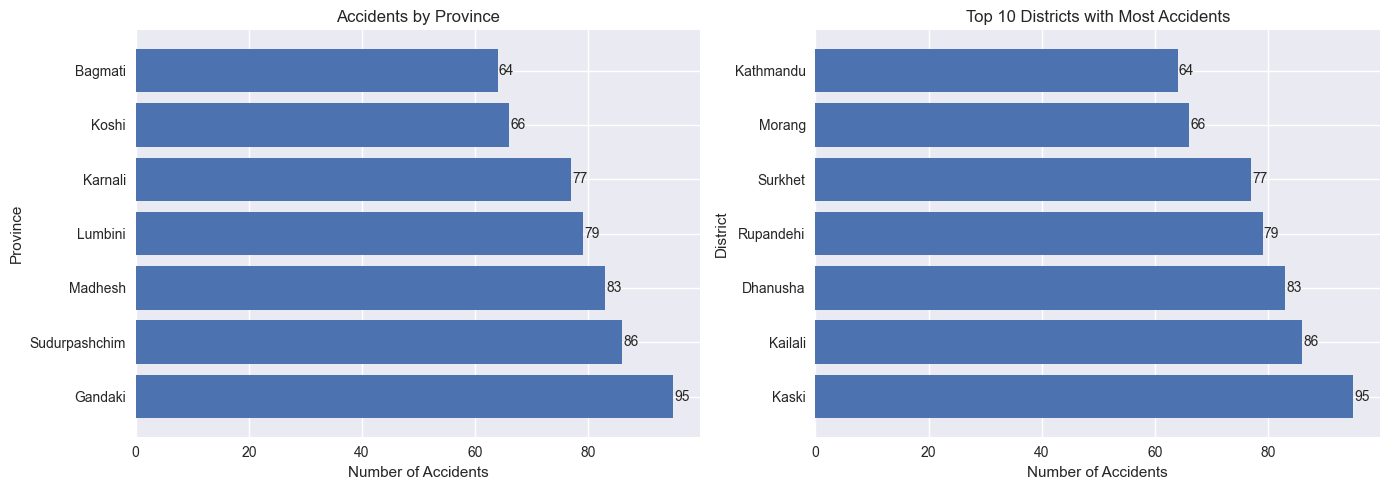

In [4]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


#count how many accidents per province
province_counts = df['Province'].value_counts()


# [PROVINCE 1 20], [PROVINCE 2 15], [PROVINCE 3 10], [PROVINCE 4 5], [PROVINCE 5 8], [PROVINCE 6 12], [PROVINCE 7 18]
axes[0].barh(province_counts.index, province_counts.values)
axes[0].set_title('Accidents by Province')
axes[0].set_xlabel('Number of Accidents')
axes[0].set_ylabel('Province')
for i, v in enumerate(province_counts.values):
    axes[0].text(v + 0.2, i, str(int(v)), va='center')

# Top 10 Districts 
district_counts = df['District'].value_counts().head(10)

axes[1].barh(district_counts.index, district_counts.values)
axes[1].set_title('Top 10 Districts with Most Accidents')
axes[1].set_xlabel('Number of Accidents')
axes[1].set_ylabel('District')
for i, v in enumerate(district_counts.values):
    axes[1].text(v + 0.2, i, str(int(v)), va='center')
plt.tight_layout()


plt.savefig('fig/province_district_accidents.png', bbox_inches='tight')


plt.show()

## Accident Cause

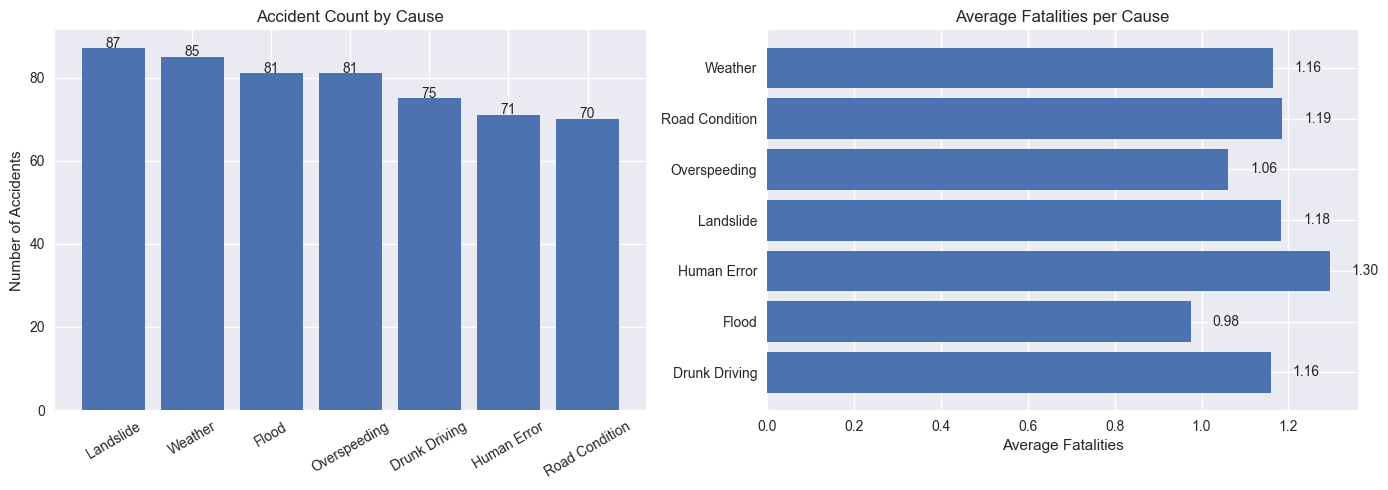

In [5]:
import matplotlib.pyplot as plt


plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Accident count by cause
cause_counts = df['Accident_Cause'].value_counts()

axes[0].bar(cause_counts.index, cause_counts.values)
axes[0].set_title('Accident Count by Cause')
axes[0].set_ylabel('Number of Accidents')
axes[0].tick_params(axis='x', rotation=30)

for i, v in enumerate(cause_counts.values):
    axes[0].text(i, v + 0.2, str(int(v)), ha='center')

# Average fatalities per cause
"""Speeding ->[2,1]
Alcohol ->[3,2]
Overloading -> [0]"""
cause_fatal = df.groupby('Accident_Cause')['Fatalities'].mean()
#[speeding 1.5], [drunk driving 2.0], [distracted driving 1.2], [weather 0.8], [road conditions 1.0], [vehicle failure 1.3], [other 0.9]
axes[1].barh(cause_fatal.index, cause_fatal.values)
axes[1].set_title('Average Fatalities per Cause')
axes[1].set_xlabel('Average Fatalities')
for i, v in enumerate(cause_fatal.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.savefig('fig/accident_cause_analysis.png', bbox_inches='tight')


plt.show()

## Vechile Type Analysis

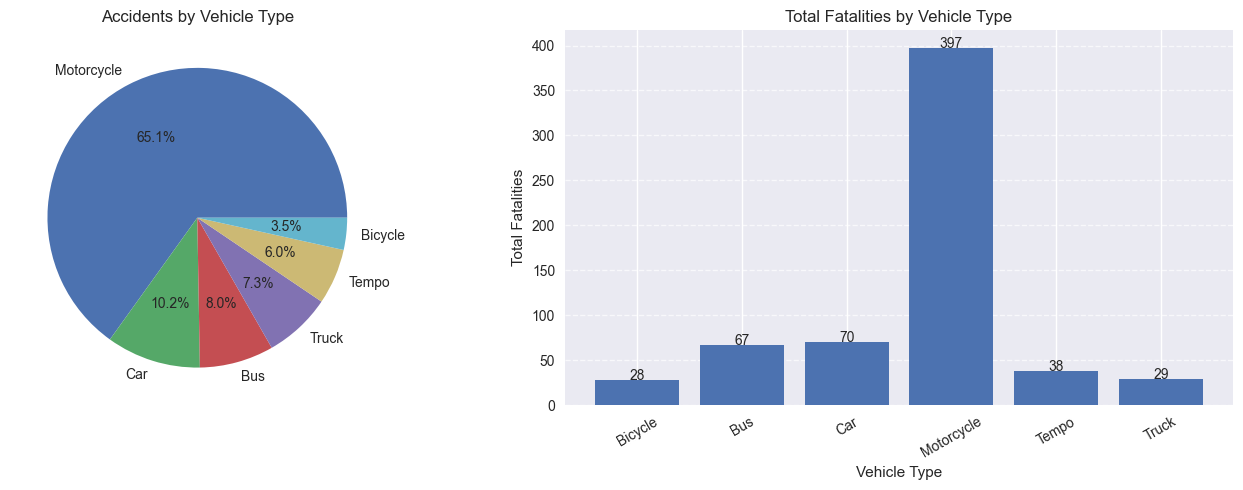

In [6]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Accidents by Vehicle Type 
veh_counts = df['Vehicle_Type'].value_counts()

axes[0].pie(
    veh_counts.values,
    labels=veh_counts.index,
    autopct='%1.1f%%'
)

axes[0].set_title('Accidents by Vehicle Type')

#  Total Fatalities by Vehicle Type 
veh_fatal = df.groupby('Vehicle_Type')['Fatalities'].sum()

axes[1].bar(veh_fatal.index, veh_fatal.values)

axes[1].set_title('Total Fatalities by Vehicle Type')
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Total Fatalities')

axes[1].tick_params(axis='x', rotation=30)

# Horizontal grid lines
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for i, v in enumerate(veh_fatal.values):
    axes[1].text(i, v + 0.2, str(int(v)), ha='center')

plt.tight_layout()

plt.savefig('fig/vehicle_type_analysis.png', bbox_inches='tight')

plt.show()

## Additional Analysis: Severity Index, Moran's I, Temporal DBSCAN & Hotspot Ranking
These additions extend the basic DBSCAN clustering with statistical validation,
severity-weighted hotspot ranking, and temporal pattern analysis.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../../Data/Nepal_RoadAccidents_Cleaned.csv')

# Re-run base DBSCAN (so this section is self-contained)
coords = np.radians(df[['Latitude', 'Longitude']].values)
db = DBSCAN(eps=0.005, min_samples=3, metric='haversine').fit(coords)
df['Cluster'] = db.labels_
print('Base DBSCAN done.')


### Step 1: Severity Index
Since our data has **Fatalities** and **Injuries** columns (no PDO flag),
we adapt the Highway Safety Manual formula:

```
SI = (353 × Fatalities) + (8 × Injuries)
```

- **353** = weight for a death (derived from crash cost ratio: NRs 7,459,501 / 21,132)
- **8** = weight for an injury (NRs 169,706 / 21,132)
- If both are 0 → PDO crash → SI = 1 (minimum score)

This ensures a single fatal crash scores far higher than many minor crashes,
making hotspot ranking meaningful for policy action.

In [ ]:
# ── SEVERITY INDEX ──────────────────────────────────────────
# Formula adapted from Highway Safety Manual (Rizal & Tiwari, 2023)
# Weights proportional to crash costs: Death=353x, Injury=8x, PDO=1x

df['Severity_Index'] = (353 * df['Fatalities']) + (8 * df['Injuries'])

# PDO crashes (no deaths, no injuries) get minimum score of 1
df.loc[(df['Fatalities'] == 0) & (df['Injuries'] == 0), 'Severity_Index'] = 1

print('=== Severity Index Summary ===')
print(df['Severity_Index'].describe().round(2))
print(f'\nPDO accidents (SI=1)    : {((df["Fatalities"]==0) & (df["Injuries"]==0)).sum()}')
print(f'Injury accidents        : {((df["Fatalities"]==0) & (df["Injuries"]>0)).sum()}')
print(f'Fatal accidents         : {(df["Fatalities"]>0).sum()}')
print(f'\nHighest SI accident:')
print(df.loc[df['Severity_Index'].idxmax(),
             ['Accident_ID','Fatalities','Injuries','Severity_Index','District','Accident_Cause']])


### Step 2: Global Moran's I
Before trusting our clusters, we statistically confirm that accidents are NOT
randomly distributed. Moran's I near +1 = clustered, near -1 = dispersed, near 0 = random.

In [ ]:
# ── GLOBAL MORAN'S I ────────────────────────────────────────
from scipy.spatial.distance import cdist

# Aggregate accidents into 0.1-degree grid cells
df['lat_bin'] = (df['Latitude'] / 0.1).astype(int)
df['lon_bin']  = (df['Longitude'] / 0.1).astype(int)
zone_counts    = df.groupby(['lat_bin','lon_bin']).size().reset_index(name='count')

n       = len(zone_counts)
x       = zone_counts['count'].values.astype(float)
x_mean  = x.mean()
zone_xy = zone_counts[['lat_bin','lon_bin']].values

# Binary weight matrix: 1 if adjacent cell, 0 otherwise
dist_mat = cdist(zone_xy, zone_xy)
W = (dist_mat <= 1.5).astype(float)
np.fill_diagonal(W, 0)

# Moran's I formula
z          = x - x_mean
numerator  = n * np.sum(W * np.outer(z, z))
denominator = W.sum() * np.sum(z**2)
morans_i   = numerator / denominator

E_I    = -1 / (n - 1)
var_I  = (n**2 * W.sum() - n * (W**2).sum() - (W.sum())**2) / \
         ((n-1) * (n+1) * (W.sum())**2 + 1e-10)
z_score = (morans_i - E_I) / (abs(var_I)**0.5 + 1e-10)

print('=== Global Moran\'s I ===')
print(f"Moran's I  : {morans_i:.4f}")
print(f'Expected I : {E_I:.4f}')
print(f'Z-score    : {z_score:.4f}')
print()
if morans_i > 0.05:
    print('Result: Accidents are SPATIALLY CLUSTERED (validates use of DBSCAN)')
elif morans_i < -0.05:
    print('Result: Accidents are DISPERSED')
else:
    print('Result: Accidents appear RANDOM at this scale')


### Step 3: Temporal DBSCAN
Run DBSCAN separately for each time of day to see if hotspot locations shift.

In [ ]:
# ── TEMPORAL DBSCAN ─────────────────────────────────────────
time_periods = ['Morning', 'Afternoon', 'Evening', 'Night']
temporal_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors_map = {-1: 'lightgrey'}
palette = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']

for idx, period in enumerate(time_periods):
    subset = df[df['Time_of_Day'] == period].copy()
    c = np.radians(subset[['Latitude','Longitude']].values)
    db_t = DBSCAN(eps=0.005, min_samples=3, metric='haversine').fit(c)
    subset['Cluster_t'] = db_t.labels_

    n_cl    = len(set(db_t.labels_)) - (1 if -1 in db_t.labels_ else 0)
    n_noise = (db_t.labels_ == -1).sum()
    temporal_results[period] = {'clusters': n_cl, 'noise': n_noise, 'total': len(subset)}

    ax = axes[idx]
    # Plot noise
    noise = subset[subset['Cluster_t'] == -1]
    ax.scatter(noise['Longitude'], noise['Latitude'], c='lightgrey', s=15, label='Noise', zorder=1)
    # Plot clusters
    for cl in sorted(subset['Cluster_t'].unique()):
        if cl == -1: continue
        pts = subset[subset['Cluster_t'] == cl]
        ax.scatter(pts['Longitude'], pts['Latitude'],
                   c=palette[cl % len(palette)], s=25, label=f'C{cl}', zorder=2)
    ax.set_title(f'{period}  |  {n_cl} clusters, {n_noise} noise')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(fontsize=7, ncol=4)

plt.suptitle('Temporal DBSCAN: Accident Hotspots by Time of Day', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig/temporal_dbscan.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== Temporal Summary ===')
for p, r in temporal_results.items():
    print(f"{p:12s} → {r['clusters']} clusters, {r['noise']} noise, {r['total']} accidents")


### Step 4: Hotspot Ranking by Severity Index
Each cluster is scored using the Severity Index. This ranks hotspots by *impact*, not just frequency.

In [ ]:
# ── HOTSPOT RANKING ──────────────────────────────────────────
hotspot_rank = df[df['Cluster'] != -1].groupby('Cluster').agg(
    Total_Accidents  = ('Accident_ID', 'count'),
    Total_Fatalities = ('Fatalities', 'sum'),
    Total_Injuries   = ('Injuries', 'sum'),
    Total_SI         = ('Severity_Index', 'sum'),
    Avg_SI_per_crash = ('Severity_Index', 'mean'),
    Top_Cause        = ('Accident_Cause', lambda x: x.mode()[0]),
    Top_Road_Type    = ('Road_Type', lambda x: x.mode()[0]),
    Top_District     = ('District', lambda x: x.mode()[0]),
    Top_Time         = ('Time_of_Day', lambda x: x.mode()[0]),
    Centroid_Lat     = ('Latitude', 'mean'),
    Centroid_Lon     = ('Longitude', 'mean'),
).round(2).sort_values('Total_SI', ascending=False)

hotspot_rank.insert(0, 'Rank', range(1, len(hotspot_rank)+1))

print('=== Hotspot Cluster Rankings ===')
display_cols = ['Rank','Total_Accidents','Total_Fatalities','Total_Injuries',
                'Total_SI','Avg_SI_per_crash','Top_Cause','Top_District','Top_Time']
print(hotspot_rank[display_cols].to_string())

# Bar chart of rankings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"Cluster {i}" for i in hotspot_rank.index]

axes[0].barh(labels, hotspot_rank['Total_SI'], color='#e41a1c')
axes[0].set_xlabel('Total Severity Index')
axes[0].set_title('Hotspot Ranking by Severity Index')
axes[0].invert_yaxis()
for i, v in enumerate(hotspot_rank['Total_SI']):
    axes[0].text(v + 50, i, f'{int(v):,}', va='center', fontsize=9)

axes[1].barh(labels, hotspot_rank['Total_Fatalities'], color='#377eb8')
axes[1].set_xlabel('Total Fatalities')
axes[1].set_title('Hotspot Ranking by Fatality Count')
axes[1].invert_yaxis()
for i, v in enumerate(hotspot_rank['Total_Fatalities']):
    axes[1].text(v + 0.5, i, str(int(v)), va='center', fontsize=9)

plt.suptitle('Comparison: Severity Index vs Raw Fatality Ranking', fontsize=12)
plt.tight_layout()
plt.savefig('fig/hotspot_ranking.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nNote: Rankings may differ between SI and raw fatality count,\n'
      'showing that frequency alone does not capture true crash severity.')


### Step 5: Severity-Weighted DBSCAN
Re-run DBSCAN where high-severity accidents have more influence by repeating rows proportionally to their SI.

In [ ]:
# ── SEVERITY-WEIGHTED DBSCAN ─────────────────────────────────
# Repeat each row proportional to its severity weight
# Scale down to avoid memory issues (divide by 10, min 1 repeat)
df['repeat_count'] = np.maximum(1, (df['Severity_Index'] / 50).astype(int))
df_weighted = df.loc[df.index.repeat(df['repeat_count'])].reset_index(drop=True)

coords_w = np.radians(df_weighted[['Latitude','Longitude']].values)
db_w = DBSCAN(eps=0.005, min_samples=3, metric='haversine').fit(coords_w)
df_weighted['Cluster_W'] = db_w.labels_

n_cl_w    = len(set(db_w.labels_)) - (1 if -1 in db_w.labels_ else 0)
n_noise_w = (db_w.labels_ == -1).sum()

print('=== Severity-Weighted DBSCAN ===')
print(f'Original DBSCAN  → {len(set(db.labels_)) - 1} clusters')
print(f'Weighted DBSCAN  → {n_cl_w} clusters')
print()
print('Interpretation:')
print('  If weighted version finds more clusters → fatal crashes reveal hidden hotspots')
print('  If fewer clusters → some frequency clusters were driven by minor crashes only')
